# PatchCore WRN50 Memory-Bank And Feature Sweep

This notebook is the next improvement pass for the labeled `120k / 10k / 20k` WideResNet50-2 PatchCore workflow.

It is built around four concrete moves:

- larger memory-bank source coverage
- normal-only memory sampling
- `96 / 128` image size
- `layer1` inclusion sweeps

Why this notebook exists:

- threshold tuning improved the operating point, but it did not improve AUROC or AUPRC
- the current `50k` memory bank only needs about `64` source wafers for `layer2 + layer3`, and even fewer when `layer1` is included
- some of that source-image budget can be wasted if anomalous train rows are sampled before the memory bank is filtered to normals
- subtle local defects are still the likely failure mode, so more spatial detail and shallower features are the next reasonable bets

Default behavior is safe: this notebook shows the planned experiments first, loads an existing local sweep bundle when available, and only runs experiments if `RUN_EXPERIMENTS = True`.


In [36]:
from __future__ import annotations

import json
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from torch.utils.data import DataLoader


def resolve_notebook_root(start: Path | None = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'helpers' / 'patchcore_wrn50_modal.py').exists():
            return candidate
        nested = candidate / 'notebooks' / 'anomaly_120k_labeled'
        if (nested / 'helpers' / 'patchcore_wrn50_modal.py').exists():
            return nested
    raise FileNotFoundError('Could not locate the WRN50 labeled notebook root.')


def resolve_project_root(start: Path | None = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'notebooks').exists() and (candidate / 'data').exists():
            return candidate
    if os.environ.get('WM811K_DATA_ROOT') or os.environ.get('WM811K_OUTPUT_ROOT'):
        return start_path
    raise FileNotFoundError('Could not locate the project root.')


NOTEBOOK_ROOT = resolve_notebook_root()
PROJECT_ROOT = resolve_project_root(NOTEBOOK_ROOT)
HELPERS_ROOT = NOTEBOOK_ROOT / 'helpers'
if str(HELPERS_ROOT) not in sys.path:
    sys.path.insert(0, str(HELPERS_ROOT))

from patchcore_wrn50_modal import (
    NORMAL_ONLY_TRAIN_SPLIT_CONFIG,
    WaferArrayDataset,
    auto_find_raw_pickle,
    defect_type_summary,
    prepare_dataset,
    resolve_device,
    run_patchcore_variant,
    set_seed,
    split_summary_wide,
)


In [ ]:
DEFAULT_LOCAL_RAW_PICKLE = PROJECT_ROOT / 'data' / 'raw' / 'LSWMD.pkl'
RAW_PICKLE = os.environ.get('WM811K_RAW_PICKLE') or (str(DEFAULT_LOCAL_RAW_PICKLE) if DEFAULT_LOCAL_RAW_PICKLE.exists() else None)

SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 0
DEVICE = 'auto'
PRETRAINED = True
FREEZE_BACKBONE = True
NORMALIZE_IMAGENET = True
BACKBONE_INPUT_SIZE = 224
QUERY_CHUNK_SIZE = 512
QUERY_CHUNK_SIZE = 512
MEMORY_CHUNK_SIZE = 4096
THRESHOLD_QUANTILE = 0.95
THRESHOLD_STRATEGY = 'validation_normal_quantile'
MAX_VALIDATION_FALSE_POSITIVE_RATE = None
SPLIT_CONFIG = NORMAL_ONLY_TRAIN_SPLIT_CONFIG.copy()
DATA_ROOT = Path(os.environ.get('WM811K_DATA_ROOT', str(PROJECT_ROOT / 'data'))).resolve()
OUTPUT_ROOT = Path(os.environ.get('WM811K_OUTPUT_ROOT', str(PROJECT_ROOT / 'artifacts'))).resolve()
ARTIFACT_BASENAME = 'patchcore_wrn50_multilayer_120k_notebook4_normal_only_x224'
ARTIFACT_ROOT = OUTPUT_ROOT / ARTIFACT_BASENAME
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

def resolve_existing_results_root(project_root: Path, artifact_root: Path) -> Path | None:
    override = os.environ.get('WM811K_NOTEBOOK4_RESULTS_ROOT')
    if override:
        override_path = Path(override).resolve()
        if (override_path / 'notebook4_results.csv').exists():
            return override_path

    local_results_root = project_root / 'outputs' / 'modal_runs'
    if local_results_root.exists():
        for run_root in sorted(local_results_root.glob('patchcore_wrn50_120k_*'), reverse=True):
            candidate = run_root / ARTIFACT_BASENAME
            if (candidate / 'notebook4_results.csv').exists():
                return candidate

    if (artifact_root / 'notebook4_results.csv').exists():
        return artifact_root
    return None

EXISTING_RESULTS_ROOT = resolve_existing_results_root(PROJECT_ROOT, ARTIFACT_ROOT)

RUN_EXPERIMENTS = False
ACTIVE_GROUPS = ['coverage_sampling', 'image_size', 'layer_sweep']
REVIEW_EXPERIMENT_NAME = None  # Set to an experiment name to override the best-F1 default in the confusion view.

DOWNSAMPLE_MAP = {'layer1': 4, 'layer2': 8, 'layer3': 16, 'layer4': 32}


def patches_per_image_for_layers(teacher_layers: list[str], backbone_input_size: int = BACKBONE_INPUT_SIZE) -> int:
    output_spatial = max(1, backbone_input_size // min(DOWNSAMPLE_MAP[layer] for layer in teacher_layers))
    return int(output_spatial * output_spatial)


def default_source_images(memory_bank_size: int, teacher_layers: list[str]) -> int:
    return int(math.ceil(memory_bank_size / patches_per_image_for_layers(teacher_layers)))


def make_experiment(
    *,
    name: str,
    group: str,
    image_size: int,
    teacher_layers: list[str],
    memory_bank_size: int = 240_000,
    topk_ratio: float = 0.05,
    reduction: str = 'topk_mean',
    patch_nn_k: int = 3,
    memory_source_images: int | None = None,
    normal_only_memory_sampling: bool = True,
    note: str = '',
) -> dict[str, object]:
    teacher_layers = [str(layer).lower() for layer in teacher_layers]
    return {
        'name': name,
        'group': group,
        'image_size': int(image_size),
        'teacher_layers': teacher_layers,
        'memory_bank_size': int(memory_bank_size),
        'topk_ratio': float(topk_ratio),
        'reduction': str(reduction),
        'patch_nn_k': int(patch_nn_k),
        'memory_source_images': memory_source_images,
        'normal_only_memory_sampling': bool(normal_only_memory_sampling),
        'note': str(note),
        'expected_patches_per_image': patches_per_image_for_layers(teacher_layers),
        'default_source_images': default_source_images(memory_bank_size, teacher_layers),
    }


EXPERIMENT_SPECS = [
    make_experiment(
        name='coverage__control_224_l23_mb50k_mean_knn1_auto_mixed',
        group='coverage_sampling',
        image_size=224,
        teacher_layers=['layer2', 'layer3'],
        memory_bank_size=50_000,
        reduction='mean',
        topk_ratio=0.10,
        patch_nn_k=1,
        memory_source_images=None,
        normal_only_memory_sampling=False,
        note='Current normal-only x224 control before the CT-style scorer and wider source coverage.',
    ),
    make_experiment(
        name='coverage__224_l23_mb240k_topk005_knn3_normals_1024src',
        group='coverage_sampling',
        image_size=224,
        teacher_layers=['layer2', 'layer3'],
        memory_source_images=1024,
        normal_only_memory_sampling=True,
        note='CT-style control recipe with larger bank, k=3 scoring, and moderate normal-only source coverage.',
    ),
    make_experiment(
        name='coverage__224_l23_mb240k_topk005_knn3_normals_2048src',
        group='coverage_sampling',
        image_size=224,
        teacher_layers=['layer2', 'layer3'],
        memory_source_images=2048,
        normal_only_memory_sampling=True,
        note='Main coverage candidate for the next pass.',
    ),
    make_experiment(
        name='coverage__224_l23_mb240k_topk005_knn3_normals_8192src',
        group='coverage_sampling',
        image_size=224,
        teacher_layers=['layer2', 'layer3'],
        memory_source_images=8192,
        normal_only_memory_sampling=True,
        note='Aggressive coverage test to estimate the upper bound from more normal source wafers.',
    ),
    make_experiment(
        name='image__128_l23_mb240k_topk005_knn3_normals_2048src',
        group='image_size',
        image_size=128,
        teacher_layers=['layer2', 'layer3'],
        memory_source_images=2048,
        normal_only_memory_sampling=True,
        note='CT-branch-style pragmatic image size for WRN50 under the stronger normal-only recipe.',
    ),
    make_experiment(
        name='image__224_l23_mb240k_topk005_knn3_normals_2048src',
        group='image_size',
        image_size=224,
        teacher_layers=['layer2', 'layer3'],
        memory_source_images=2048,
        normal_only_memory_sampling=True,
        note='Direct x224 comparison point under the stronger normal-only recipe.',
    ),
    make_experiment(
        name='layer__224_l12_mb240k_topk005_knn3_normals_2048src',
        group='layer_sweep',
        image_size=224,
        teacher_layers=['layer1', 'layer2'],
        memory_source_images=2048,
        normal_only_memory_sampling=True,
        note='Shallower feature mix to test compact defect sensitivity under the stronger recipe.',
    ),
    make_experiment(
        name='layer__224_l123_mb240k_topk005_knn3_normals_2048src',
        group='layer_sweep',
        image_size=224,
        teacher_layers=['layer1', 'layer2', 'layer3'],
        memory_source_images=2048,
        normal_only_memory_sampling=True,
        note='Layer1 inclusion while keeping the current deeper features under the stronger recipe.',
    ),
]

plan_df = pd.DataFrame(EXPERIMENT_SPECS)
plan_df['teacher_layers_label'] = plan_df['teacher_layers'].apply(lambda layers: ' + '.join(layers))
plan_df['requested_source_images'] = plan_df['memory_source_images'].fillna(plan_df['default_source_images'])
plan_df.to_csv(ARTIFACT_ROOT / 'notebook4_experiment_plan.csv', index=False)


In [38]:
display(
    plan_df[
        [
            'group',
            'name',
            'image_size',
            'teacher_layers_label',
            'memory_bank_size',
            'default_source_images',
            'requested_source_images',
            'normal_only_memory_sampling',
            'expected_patches_per_image',
            'note',
        ]
    ]
)

active_plan_df = plan_df[plan_df['group'].isin(ACTIVE_GROUPS)].reset_index(drop=True)
print(f'Notebook root: {NOTEBOOK_ROOT}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Data root: {DATA_ROOT}')
print(f'Artifact root: {ARTIFACT_ROOT}')
print(f'Existing results root: {EXISTING_RESULTS_ROOT}')
print(f'Configured raw pickle: {RAW_PICKLE}')
print(f'RUN_EXPERIMENTS = {RUN_EXPERIMENTS}')
print(f'Active groups: {ACTIVE_GROUPS}')
print(f'Review experiment override: {REVIEW_EXPERIMENT_NAME}')
print(f'Planned experiments in active groups: {len(active_plan_df)}')


,group,name,image_size,teacher_layers_label,memory_bank_size,default_source_images,requested_source_images,normal_only_memory_sampling,expected_patches_per_image,note
0,coverage_sampling,coverage__baseline_64_l23_auto_mixed,64,layer2 + layer3,50000,64,64.0,False,784,Current-style control: mixed source-image samp...
1,coverage_sampling,coverage__64_l23_normals_512src,64,layer2 + layer3,50000,64,512.0,True,784,Increase source-image coverage while forcing n...
2,coverage_sampling,coverage__64_l23_normals_2048src,64,layer2 + layer3,50000,64,2048.0,True,784,Main coverage candidate for the next pass.
3,coverage_sampling,coverage__64_l23_normals_8192src,64,layer2 + layer3,50000,64,8192.0,True,784,Aggressive coverage test to see whether more s...
4,image_size,image__96_l23_normals_2048src,96,layer2 + layer3,50000,64,2048.0,True,784,Increase wafer-map detail while keeping the st...
5,image_size,image__128_l23_normals_2048src,128,layer2 + layer3,50000,64,2048.0,True,784,Highest-detail image-size check before changin...
6,layer_sweep,layer__96_l12_normals_2048src,96,layer1 + layer2,50000,16,2048.0,True,3136,Shallower feature mix to test compact defect s...
7,layer_sweep,layer__96_l123_normals_2048src,96,layer1 + layer2 + layer3,50000,16,2048.0,True,3136,Layer1 inclusion without dropping the current ...
8,layer_sweep,layer__128_l123_normals_2048src,128,layer1 + layer2 + layer3,50000,16,2048.0,True,3136,Highest-detail plus layer1 inclusion stress test.


Notebook root: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\notebooks\anomaly_120k_labeled
Project root: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project
Data root: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\data
Artifact root: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\artifacts\patchcore_wrn50_multilayer_120k_notebook4
Existing results root: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\outputs\modal_runs\patchcore_wrn50_120k_20260322_notebook4_fetch\patchcore_wrn50_multilayer_120k_notebook4
Configured raw pickle: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\data\raw\LSWMD.pkl
RUN_EXPERIMENTS = False
Active groups: ['coverage_sampling', 'image_size', 'layer_sweep']
Review experiment override: None
Planned experiments in active groups: 9


In [39]:
dataset_cache: dict[int, dict[str, object]] = {}


def load_split_resources(image_size: int, raw_pickle: Path) -> dict[str, object]:
    image_size = int(image_size)
    if image_size in dataset_cache:
        return dataset_cache[image_size]

    metadata_path = prepare_dataset(
        raw_pickle,
        DATA_ROOT,
        image_size,
        SPLIT_CONFIG,
        seed=SEED,
        overwrite=False,
    )
    metadata = pd.read_csv(metadata_path)
    resources = {
        'metadata_path': metadata_path,
        'metadata': metadata,
        'train_dataset': WaferArrayDataset(metadata_path, split='train', data_root=DATA_ROOT),
        'val_dataset': WaferArrayDataset(metadata_path, split='val', data_root=DATA_ROOT),
        'test_dataset': WaferArrayDataset(metadata_path, split='test', data_root=DATA_ROOT),
    }
    resources['val_loader'] = DataLoader(
        resources['val_dataset'],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    resources['test_loader'] = DataLoader(
        resources['test_dataset'],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    dataset_cache[image_size] = resources
    return resources


def run_experiment(spec: dict[str, object], raw_pickle: Path, device: torch.device) -> tuple[dict[str, object], dict[str, object]]:
    resources = load_split_resources(int(spec['image_size']), raw_pickle)
    variant = {
        'name': str(spec['name']),
        'memory_bank_size': int(spec['memory_bank_size']),
        'reduction': str(spec['reduction']),
        'topk_ratio': float(spec['topk_ratio']),
        'patch_nn_k': int(spec['patch_nn_k']),
        'memory_source_images': spec['memory_source_images'],
        'normal_only_memory_sampling': bool(spec['normal_only_memory_sampling']),
    }
    result = run_patchcore_variant(
        variant,
        train_dataset=resources['train_dataset'],
        val_loader=resources['val_loader'],
        test_loader=resources['test_loader'],
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        device=device,
        output_dir=ARTIFACT_ROOT / str(spec['group']),
        seed=SEED,
        teacher_layers=list(spec['teacher_layers']),
        pretrained=PRETRAINED,
        freeze_backbone=FREEZE_BACKBONE,
        backbone_input_size=BACKBONE_INPUT_SIZE,
        normalize_imagenet=NORMALIZE_IMAGENET,
        threshold_quantile=THRESHOLD_QUANTILE,
        threshold_strategy=THRESHOLD_STRATEGY,
        max_validation_false_positive_rate=MAX_VALIDATION_FALSE_POSITIVE_RATE,
        query_chunk_size=QUERY_CHUNK_SIZE,
        memory_chunk_size=MEMORY_CHUNK_SIZE,
    )
    row = {
        **result['row'],
        'group': str(spec['group']),
        'image_size': int(spec['image_size']),
        'teacher_layers_label': ' + '.join(spec['teacher_layers']),
        'note': str(spec['note']),
    }
    return row, result


results_df = pd.DataFrame()
experiment_results: dict[str, dict[str, object]] = {}
loaded_summary: dict[str, object] | None = None

if EXISTING_RESULTS_ROOT is not None:
    existing_results_path = EXISTING_RESULTS_ROOT / 'notebook4_results.csv'
    existing_summary_path = EXISTING_RESULTS_ROOT / 'notebook4_summary.json'
    results_df = pd.read_csv(existing_results_path)
    if existing_summary_path.exists():
        loaded_summary = json.loads(existing_summary_path.read_text(encoding='utf-8'))


In [40]:
if not RUN_EXPERIMENTS:
    if results_df.empty:
        display(Markdown("""### Execution is disabled

Set `RUN_EXPERIMENTS = True` in the config cell when you want to launch the sweep.

No local `notebook4_results.csv` bundle was found yet, so the summary sections below will stay empty until you either run the sweep or point `WM811K_NOTEBOOK4_RESULTS_ROOT` at an existing local export."""))
    else:
        display(Markdown(f"""### Loaded existing local results

Execution is disabled, so this notebook is showing the saved sweep bundle from `{EXISTING_RESULTS_ROOT}`.

Set `RUN_EXPERIMENTS = True` in the config cell if you want to rerun the sweep locally."""))
else:
    set_seed(SEED)
    device = resolve_device(DEVICE)
    raw_pickle = Path(auto_find_raw_pickle(RAW_PICKLE)).resolve()
    print(f'Using device: {device}')
    print(f'Raw pickle: {raw_pickle}')

    active_specs = [spec for spec in EXPERIMENT_SPECS if spec['group'] in ACTIVE_GROUPS]
    rows = []

    for spec in active_specs:
        print(f"\n=== Running experiment: {spec['name']} ===")
        print(
            f"group={spec['group']} | image_size={spec['image_size']} | "
            f"layers={' + '.join(spec['teacher_layers'])} | "
            f"source_images={spec['memory_source_images']} | "
            f"normal_only={spec['normal_only_memory_sampling']}"
        )
        row, result = run_experiment(spec, raw_pickle=raw_pickle, device=device)
        experiment_results[str(spec['name'])] = result
        rows.append(row)

    results_df = pd.DataFrame(rows).sort_values(['f1', 'auroc', 'auprc'], ascending=False).reset_index(drop=True)
    results_df.to_csv(ARTIFACT_ROOT / 'notebook4_results.csv', index=False)

    bundle_summary = {
        'threshold_strategy': THRESHOLD_STRATEGY,
        'max_validation_false_positive_rate': MAX_VALIDATION_FALSE_POSITIVE_RATE,
        'batch_size': BATCH_SIZE,
        'device': str(device),
        'raw_pickle': str(raw_pickle),
        'active_groups': ACTIVE_GROUPS,
        'experiments': results_df.to_dict(orient='records'),
    }
    (ARTIFACT_ROOT / 'notebook4_summary.json').write_text(json.dumps(bundle_summary, indent=2), encoding='utf-8')

    display(results_df)


### Loaded existing local results

Execution is disabled, so this notebook is showing the saved sweep bundle from `C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\outputs\modal_runs\patchcore_wrn50_120k_20260322_notebook4_fetch\patchcore_wrn50_multilayer_120k_notebook4`.

Set `RUN_EXPERIMENTS = True` in the config cell if you want to rerun the sweep locally.

,group,name,image_size,teacher_layers_label,memory_source_images_requested,normal_only_memory_sampling,precision,recall,f1,auroc,auprc,false_positive_rate
0,coverage_sampling,coverage__64_l23_normals_8192src,64,layer2 + layer3,8192.0,True,0.5627,0.619,0.5895,0.9323,0.5859,0.0253
1,image_size,image__128_l23_normals_2048src,128,layer2 + layer3,2048.0,True,0.5488,0.635,0.5888,0.9305,0.5124,0.0275
2,layer_sweep,layer__128_l123_normals_2048src,128,layer1 + layer2 + layer3,2048.0,True,0.5053,0.569,0.5353,0.8940,0.4346,0.0293


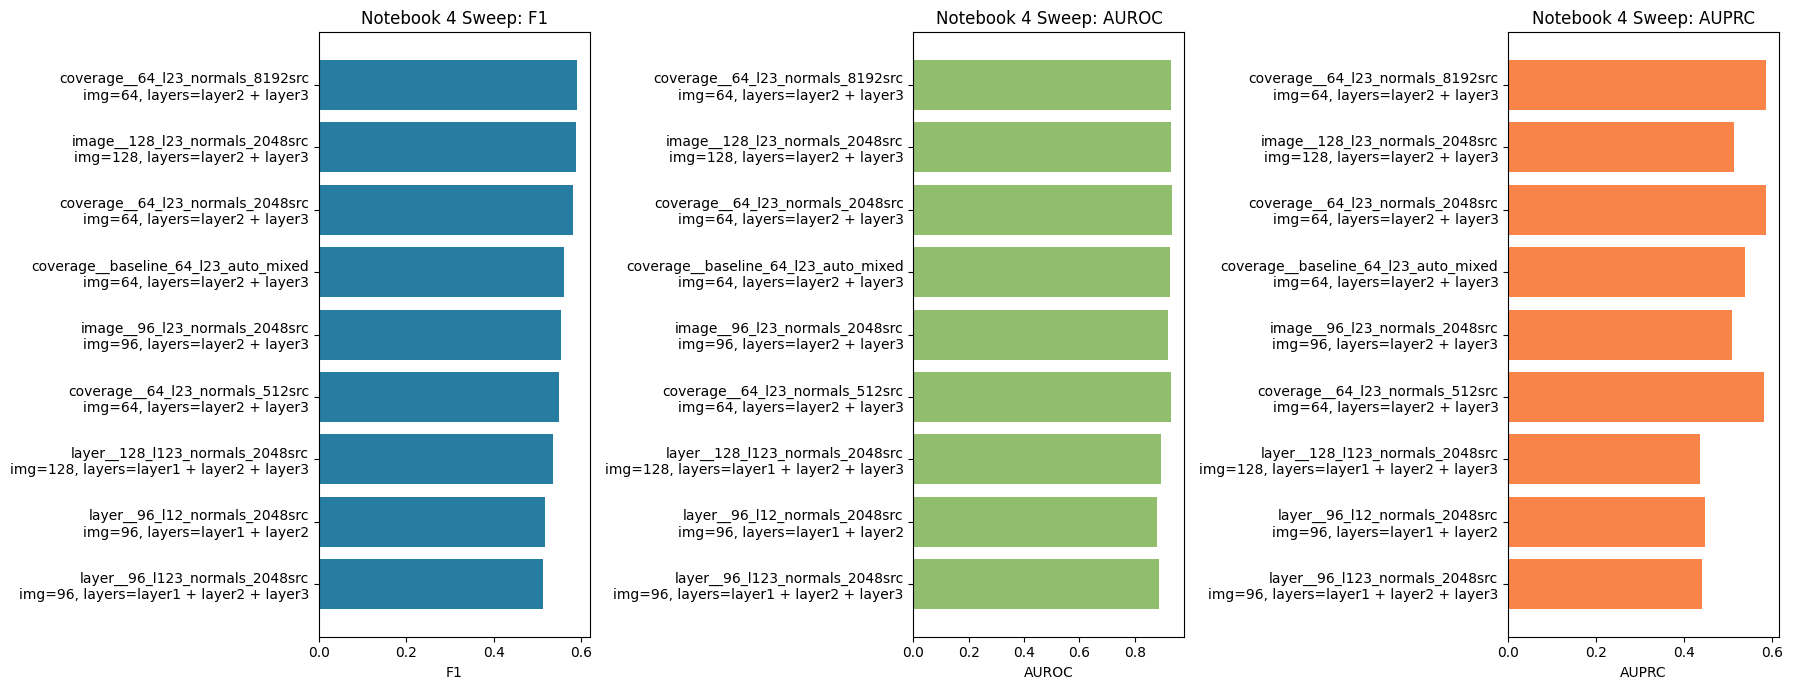

In [41]:
if results_df.empty:
    display(Markdown("""### No experiment results yet

The plan table above is ready. Once the sweep runs, this section will summarize the best result in each group."""))
else:
    best_by_group_df = (
        results_df.sort_values(['f1', 'auroc', 'auprc'], ascending=False)
        .groupby('group', as_index=False)
        .first()
    )
    display(best_by_group_df[[
        'group',
        'name',
        'image_size',
        'teacher_layers_label',
        'memory_source_images_requested',
        'normal_only_memory_sampling',
        'precision',
        'recall',
        'f1',
        'auroc',
        'auprc',
        'false_positive_rate',
    ]].round(4))

    plot_df = results_df.copy()
    plot_df['label'] = (
        plot_df['name']
        + '\nimg=' + plot_df['image_size'].astype(str)
        + ', layers=' + plot_df['teacher_layers_label']
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    axes[0].barh(plot_df['label'], plot_df['f1'], color='#277da1')
    axes[0].set_title('Notebook 4 Sweep: F1')
    axes[0].set_xlabel('F1')
    axes[0].invert_yaxis()

    axes[1].barh(plot_df['label'], plot_df['auroc'], color='#90be6d')
    axes[1].set_title('Notebook 4 Sweep: AUROC')
    axes[1].set_xlabel('AUROC')
    axes[1].invert_yaxis()

    axes[2].barh(plot_df['label'], plot_df['auprc'], color='#f9844a')
    axes[2].set_title('Notebook 4 Sweep: AUPRC')
    axes[2].set_xlabel('AUPRC')
    axes[2].invert_yaxis()

    plt.tight_layout()
    plt.show()


In [42]:
if results_df.empty:
    guidance = """
### Recommended Execution Order

1. Run `coverage_sampling` first. That isolates whether the stronger CT-style scorer and much wider normal-only source coverage beat the current normal-only x224 control.
2. If `coverage__224_l23_mb240k_topk005_knn3_normals_2048src` or `...8192src` wins, run `image_size` next to compare `128` against the direct `224` control under that stronger recipe.
3. Run `layer_sweep` last. Once we know whether `128` or `224` is the better stored wafer size, we can judge whether `layer1` adds signal or just more noise and compute.
"""
    display(Markdown(guidance))
else:
    best_row = results_df.sort_values(['f1', 'auroc', 'auprc'], ascending=False).iloc[0]
    message = f"""
### Working Recommendation

- Best overall experiment so far: **{best_row['name']}**
- Image size: `{int(best_row['image_size'])}`
- Teacher layers: `{best_row['teacher_layers_label']}`
- Requested source images: `{best_row['memory_source_images_requested']}`
- Normal-only memory sampling: `{bool(best_row['normal_only_memory_sampling'])}`
- Test precision / recall / F1: `{best_row['precision']:.4f} / {best_row['recall']:.4f} / {best_row['f1']:.4f}`
- AUROC / AUPRC: `{best_row['auroc']:.4f} / {best_row['auprc']:.4f}`

If the winning config comes from the coverage sweep, the next move should be to keep that stronger memory-bank recipe and continue with the image-size and `layer1` comparisons. If the winner already includes `96 / 128` or `layer1`, that should become the new control for the next remote training run.
"""
    display(Markdown(message))



### Working Recommendation

- Best overall experiment so far: **coverage__64_l23_normals_8192src**
- Image size: `64`
- Teacher layers: `layer2 + layer3`
- Requested source images: `8192.0`
- Normal-only memory sampling: `True`
- Test precision / recall / F1: `0.5627 / 0.6190 / 0.5895`
- AUROC / AUPRC: `0.9323 / 0.5859`

If the winning config comes from the coverage sweep, the next move should be to keep that stronger memory-bank recipe and continue with the image-size and `layer1` comparisons. If the winner already includes `96 / 128` or `layer1`, that should become the new control for the next remote training run.


,item,value
0,experiment,coverage__64_l23_normals_8192src
1,group,coverage_sampling
2,image_size,64
3,teacher_layers,layer2 + layer3
4,threshold,0.567186
5,local_scores_dir,C:\Users\genso\Documents\College_Projects\Deep...


ROC-AUC (test split): 0.9323
AUPRC (test split): 0.5859
Applied threshold: 0.567186
Balanced accuracy: 0.7968


,label,precision,recall,f1-score,support
0,normal,0.979841,0.974684,0.9773,19000
1,anomaly,0.562727,0.619,0.5895,1000
2,accuracy,<NA>,<NA>,0.9569,20000
3,macro avg,0.771284,0.796842,0.7834,20000
4,weighted avg,0.958986,0.9569,0.9579,20000


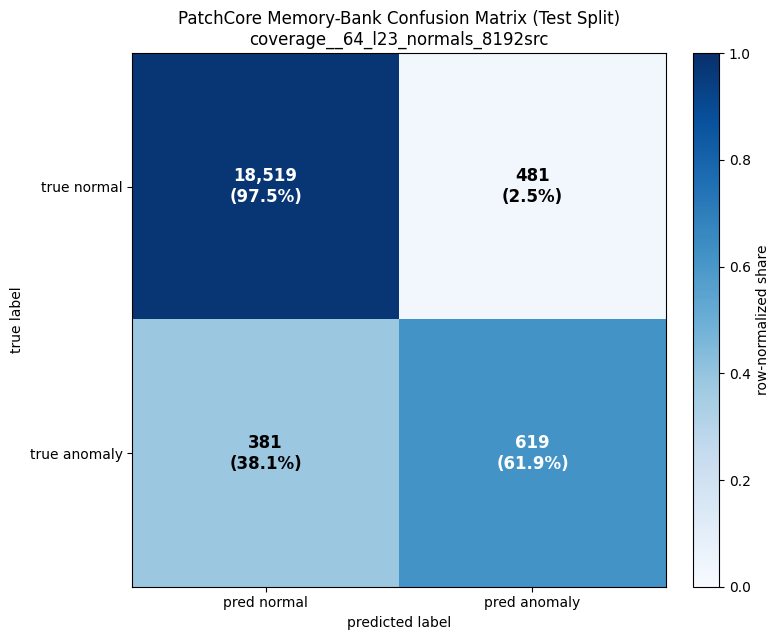

In [43]:
def resolve_local_experiment_dir(row: pd.Series) -> Path | None:
    candidates: list[Path] = []
    group_name = str(row.get('group', ''))
    experiment_name = str(row.get('name', ''))
    if group_name and experiment_name:
        if EXISTING_RESULTS_ROOT is not None:
            candidates.append(EXISTING_RESULTS_ROOT / group_name / experiment_name)
        candidates.append(ARTIFACT_ROOT / group_name / experiment_name)

    raw_output_dir = row.get('output_dir')
    if pd.notna(raw_output_dir):
        candidates.append(Path(str(raw_output_dir)))

    seen: set[Path] = set()
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if (resolved / 'test_scores.csv').exists():
            return resolved
    return None


if results_df.empty:
    display(Markdown("""### Memory-bank confusion view unavailable

No experiment results are loaded yet, so there is nothing to score here."""))
else:
    if REVIEW_EXPERIMENT_NAME:
        matched_rows = results_df.loc[results_df['name'] == REVIEW_EXPERIMENT_NAME]
        if matched_rows.empty:
            raise ValueError(f"Experiment not found in results_df: {REVIEW_EXPERIMENT_NAME}")
        review_row = matched_rows.iloc[0]
    else:
        review_row = results_df.sort_values(['f1', 'auroc', 'auprc'], ascending=False).iloc[0]

    review_dir = resolve_local_experiment_dir(review_row)
    if review_dir is None:
        display(Markdown(
            f"""### Memory-bank confusion view unavailable

I found the selected experiment row for `{review_row['name']}`, but I could not locate a local `test_scores.csv` folder for it."""
        ))
    else:
        test_scores_df = pd.read_csv(review_dir / 'test_scores.csv')
        threshold = float(review_row['threshold'])
        y_true = test_scores_df['is_anomaly'].astype(int)
        y_score = test_scores_df['score'].astype(float)
        y_pred = (y_score > threshold).astype(int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        class_precision, class_recall, class_f1, class_support = precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1],
            zero_division=0,
        )
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        )
        weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0,
        )

        review_info_df = pd.DataFrame(
            [
                {'item': 'experiment', 'value': str(review_row['name'])},
                {'item': 'group', 'value': str(review_row['group'])},
                {'item': 'image_size', 'value': int(review_row['image_size'])},
                {'item': 'teacher_layers', 'value': str(review_row['teacher_layers_label'])},
                {'item': 'threshold', 'value': threshold},
                {'item': 'local_scores_dir', 'value': str(review_dir)},
            ]
        )
        classification_report_df = pd.DataFrame(
            [
                {
                    'label': 'normal',
                    'precision': float(class_precision[0]),
                    'recall': float(class_recall[0]),
                    'f1-score': float(class_f1[0]),
                    'support': int(class_support[0]),
                },
                {
                    'label': 'anomaly',
                    'precision': float(class_precision[1]),
                    'recall': float(class_recall[1]),
                    'f1-score': float(class_f1[1]),
                    'support': int(class_support[1]),
                },
                {
                    'label': 'accuracy',
                    'precision': pd.NA,
                    'recall': pd.NA,
                    'f1-score': float(accuracy_score(y_true, y_pred)),
                    'support': int(len(y_true)),
                },
                {
                    'label': 'macro avg',
                    'precision': float(macro_precision),
                    'recall': float(macro_recall),
                    'f1-score': float(macro_f1),
                    'support': int(len(y_true)),
                },
                {
                    'label': 'weighted avg',
                    'precision': float(weighted_precision),
                    'recall': float(weighted_recall),
                    'f1-score': float(weighted_f1),
                    'support': int(len(y_true)),
                },
            ]
        )
        confusion_counts_df = pd.DataFrame(
            cm,
            index=['true normal', 'true anomaly'],
            columns=['pred normal', 'pred anomaly'],
        )
        confusion_row_share_df = confusion_counts_df.div(confusion_counts_df.sum(axis=1).replace(0, 1), axis=0)

        display(review_info_df)
        print(f"ROC-AUC (test split): {roc_auc_score(y_true, y_score):.4f}")
        print(f"AUPRC (test split): {average_precision_score(y_true, y_score):.4f}")
        print(f"Applied threshold: {threshold:.6f}")
        print(f"Balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.4f}")
        display(classification_report_df.round({'precision': 4, 'recall': 4, 'f1-score': 4}))

        fig, ax = plt.subplots(figsize=(8, 6.5))
        image = ax.imshow(confusion_row_share_df.values, cmap='Blues', vmin=0.0, vmax=1.0)
        ax.set_title(f"PatchCore Memory-Bank Confusion Matrix (Test Split)\n{review_row['name']}")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(confusion_counts_df.columns)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(confusion_counts_df.index)
        ax.set_xlabel('predicted label')
        ax.set_ylabel('true label')

        for row_index in range(confusion_counts_df.shape[0]):
            for col_index in range(confusion_counts_df.shape[1]):
                count = int(confusion_counts_df.iat[row_index, col_index])
                share = float(confusion_row_share_df.iat[row_index, col_index])
                text_color = 'white' if share >= 0.5 else 'black'
                ax.text(
                    col_index,
                    row_index,
                    f"{count:,}\n({share:.1%})",
                    ha='center',
                    va='center',
                    color=text_color,
                    fontsize=12,
                    fontweight='bold',
                )

        plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label='row-normalized share')
        plt.tight_layout()
        plt.show()
